1. 读取数据

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import alpha

In [134]:
data = pd.read_csv('ex1data1.txt', header=None, names=['population', 'income'])
data.head()

,population,income
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [135]:
data.insert(0, 'Ones', 1)
data.head()

,Ones,population,income
0,1,6.1101,17.5920
1,1,5.5277,9.1302
2,1,8.5186,13.6620
3,1,7.0032,11.8540
4,1,5.8598,6.8233


In [136]:
def cost(x, y, theta):
    delta = x * theta.T
    delta = delta - y
    delta = np.power(delta, 2)
    value = np.sum(delta)
    value = value / (len(x) * 2)
    return value

In [137]:
def descent(x, y, theta, alpha, itr):
    paraCount = theta.shape[1]
    c = np.zeros(itr)
    for i in range(itr):
        temp = np.matrix(np.zeros(paraCount))
        for j in range(paraCount):
            delta = x * theta.T
            delta = delta - y
            delta = np.multiply(delta, x[:, j])
            value = np.sum(delta)
            value = alpha * value / len(x)
            temp[0, j] = theta[0, j] - value
        theta = temp
        c[i] = cost(x, y, theta)
    return theta, c


theta = np.matrix([0, 0])
# paraCount = theta.shape[1]
# temp = np.matrix(np.zeros(paraCount))
# temp.shape
# temp
alpha = 0.01
itr = 1000
x = np.matrix(data.iloc[:, 0:2].values)
y = np.matrix(data.iloc[:, 2:3].values)
theta, c = descent(x, y, theta, alpha, itr)


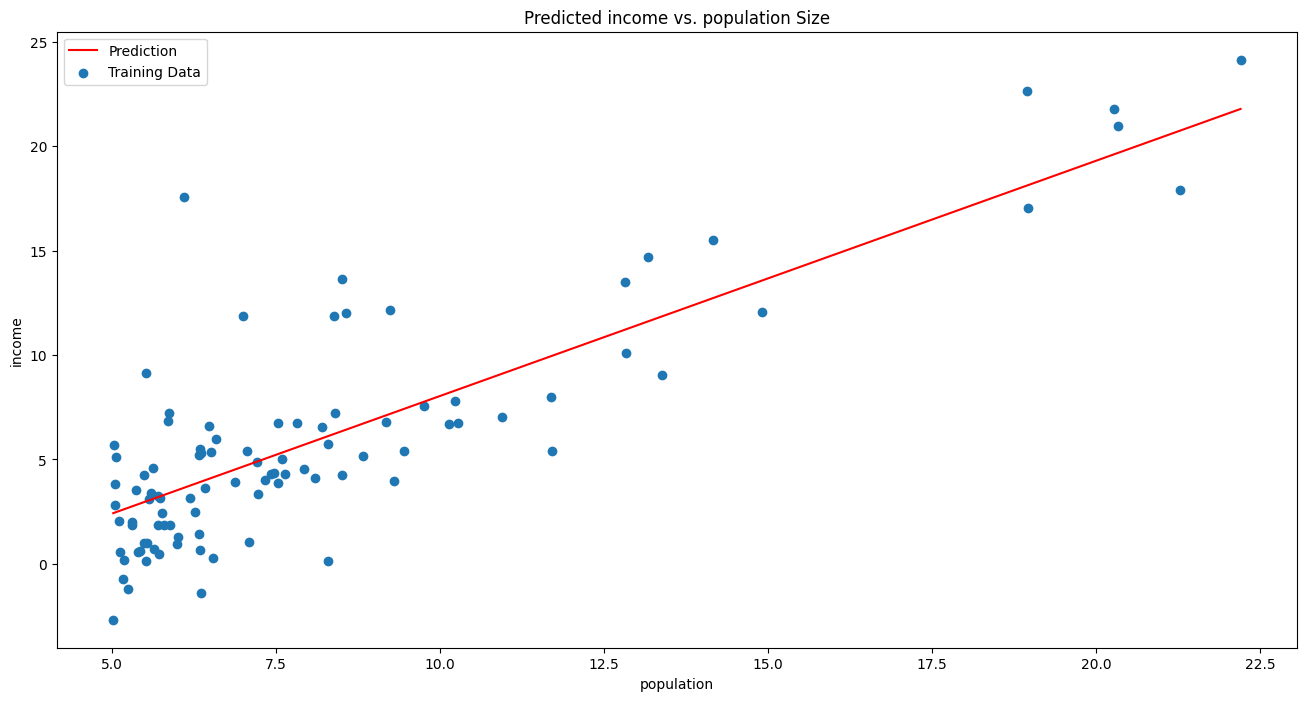

In [156]:
xAxis = np.linspace(data.population.min(), data.population.max(), 100)
# yAxis = np.linspace(data.income.min(), data.income.max())
h = theta[0, 0] + (theta[0, 1] * xAxis)

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(xAxis, h, 'red', label='Prediction')
ax.scatter(data.population, data.income, label='Training Data')
ax.legend(loc=2)

ax.set_xlabel('population')
ax.set_ylabel('income')
ax.set_title('Predicted income vs. population Size')
plt.show()

In [ ]:
data.describe()

可视化

In [ ]:
data.plot(kind='scatter', x='pop', y='income')
plt.show()